# Notebook 02 — Model Training
**FracAtlas YOLOv8m Fracture Detection Pipeline**

Trains a YOLOv8m model on the prepared dataset with medical-imaging–optimized
hyperparameters and augmentation strategy.

> **Notebook 01 must be completed successfully before running this notebook.**


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Salin file ZIP ke directory lokal Colab
!cp "/content/drive/MyDrive/FracAtlas.rar" "/content/FracAtlas.rar"

In [28]:
# Install unrar (wajib di Colab)
!sudo apt-get install unrar -y

# Ekstrak file RAR
!unrar x "/content/FracAtlas.rar" "/content/FracAtlas/"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/FracAtlas.rar

Extracting  /content/FracAtlas/fracatlas_hand_oversampled.yaml             0%  OK 

Would you like to replace the existing file /content/FracAtlas/yolo_dataset_hand_oversampled/dataset.yaml
   142 bytes, modified on 2026-06-11 04:07
with a new one
   167 bytes, modified on 2026-04-24 14:00

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit n


Would you like to replace the existing file /content/FracAtlas/yolo_dataset_hand_oversampled/test/images/IMG0000035_orig.jpg
518727 bytes, modified on 2026-04-24 13:59
with a new one
518727 bytes, modified on 2026-04-24 13:59

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit N


Would you like to replace the existin

In [29]:
!pip install ultralytics

In [30]:
import os, yaml, torch
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd

# ─── Verify GPU ───────────────────────────────────────────────────────────────
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
    print("VRAM            :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    print("No GPU detected — training will be slow on CPU.")


PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.64 GB


## 1. Configuration

In [31]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
BASE_DIR = Path("/content/FracAtlas/")
YAML_PATH = BASE_DIR / "fracatlas_hand_oversampled.yaml"
RUNS_DIR  = BASE_DIR / "runs" / "detect"

# ─── MODEL ────────────────────────────────────────────────────────────────────
# Use 'yolov8s' for small.
# Use 'yolov8m' is the balanced choice for medical imaging with augmented dataset.
# Use 'yolov8n.pt' for quick experiments,
# Use 'yolov8l.pt' for max accuracy.
MODEL_WEIGHTS = "yolov8m.pt"   # Will be downloaded automatically if not present
RUN_NAME      = "fracatlas_yolov8m_adamw"

# ─── CORE HYPERPARAMETERS ────────────────────────────────────────────────────
IMGSZ      = 640      # Keep large — X-rays have fine-detail fractures
EPOCHS     = 100
BATCH_SIZE = 4       # Reduce to 4 if CUDA OOM; increase to 16 if >16 GB VRAM
PATIENCE   = 20       # Early stopping patience (epochs without improvement)
WORKERS    = 2        # DataLoader workers

# ─── MEDICAL-OPTIMISED AUGMENTATION ──────────────────────────────────────────
# Conservative augmentations that respect anatomical structure
AUGMENTATION = dict(
    degrees   = 10.0,   # ±10° rotation — simulates patient positioning
    translate = 0.05,   # Small translation
    scale     = 0.2,    # Mild scale variation
    shear     = 0.0,    # Disabled — distorts anatomy
    perspective = 0.0,  # Disabled — X-rays are projections
    flipud    = 0.0,    # Disabled — anatomical orientation matters
    fliplr    = 0.5,    # OK for symmetric anatomy (arms/legs)
    mosaic    = 0.5,    # Reduced from 1.0 — helps but can create artifacts
    mixup     = 0.1,    # Light mixup
    copy_paste = 0.0,   # Disabled for medical
    hsv_h     = 0.0,    # X-rays are grayscale — no hue shift
    hsv_s     = 0.0,    # No saturation shift
    hsv_v     = 0.2,    # Mild brightness variation (simulate exposure differences)
)

print("- Configuration loaded")
print(f"   Model    : {MODEL_WEIGHTS}")
print(f"   YAML     : {YAML_PATH.resolve()}")
print(f"   Image sz : {IMGSZ}px")
print(f"   Epochs   : {EPOCHS} (patience={PATIENCE})")
print(f"   Batch    : {BATCH_SIZE}")


- Configuration loaded
   Model    : yolov8m.pt
   YAML     : /content/FracAtlas/fracatlas_hand_oversampled.yaml
   Image sz : 640px
   Epochs   : 100 (patience=20)
   Batch    : 4


## 2. Inspect data.yaml

In [34]:
with open(YAML_PATH) as f:
    data_cfg = yaml.safe_load(f)

print("data.yaml contents:")
for k, v in data_cfg.items():
    print(f"  {k}: {v}")

# Quick sanity: check paths resolve
dataset_path = Path(data_cfg["path"])
for split in ["train", "val", "test"]:
    n = len(list((dataset_path / split / "images").iterdir()))
    print(f"  {split}: {n} images")


data.yaml contents:
  path: /content/FracAtlas/yolo_dataset_hand_oversampled
  train: train/images
  val: val/images
  test: test/images
  nc: 1
  names: ['fracture']
  train: 1690 images
  val: 362 images
  test: 362 images


## 3. Class Distribution & Final Weighting


In [35]:
# FracAtlas was balanced via undersampling in Notebook 01 (Ratio ~1:2).
# We verify the final distribution and compute weights to guide the model.

label_dir_train = dataset_path / "train" / "labels"
n_frac     = sum(1 for f in label_dir_train.iterdir() if f.stat().st_size > 0)
n_non_frac = sum(1 for f in label_dir_train.iterdir() if f.stat().st_size == 0)
n_total    = n_frac + n_non_frac

# Weight = total / (n_classes * n_samples_for_class)
weight_frac = n_total / (2 * n_frac) if n_frac > 0 else 1.0

print(f"Final Train set distribution:")
print(f"  Fractured    : {n_frac:>5}  ({100*n_frac/n_total:.1f}%)")
print(f"  Non-fractured: {n_non_frac:>5}  ({100*n_non_frac/n_total:.1f}%)")
print(f"  Class weight (fracture): {weight_frac:.2f}")
print()
print("We handle the remaining imbalance via:")
print("   1. Undersampling (Done in Notebook 01)")
print("   2. Class weights in loss function (computed above)")
print("   3. Mosaic augmentation (helps model see more fracture examples)")


Final Train set distribution:
  Fractured    :   920  (54.4%)
  Non-fractured:   770  (45.6%)
  Class weight (fracture): 0.92

We handle the remaining imbalance via:
   1. Undersampling (Done in Notebook 01)
   2. Class weights in loss function (computed above)
   3. Mosaic augmentation (helps model see more fracture examples)


## 4. Load Model

In [36]:
# Load pretrained yolov8m backbone (downloads ~40MB if not present)
model = YOLO(MODEL_WEIGHTS)
print(f"- Model loaded: {MODEL_WEIGHTS}")
print(f"   Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

- Model loaded: yolov8m.pt
   Parameters: 25,902,640


## 5. Train

In [37]:
# ─── TRAINING ─────────────────────────────────────────────────────────────────
# All augmentation kwargs are passed directly to model.train()
results = model.train(
    data       = str(YAML_PATH),
    imgsz      = IMGSZ,
    epochs     = EPOCHS,
    batch      = BATCH_SIZE,
    patience   = PATIENCE,
    workers    = WORKERS,
    project    = str(RUNS_DIR),
    name       = RUN_NAME,
    exist_ok   = True,          # Overwrite if rerunning
    pretrained = True,
    optimizer  = "AdamW",       # AdamW
    lr0        = 0.001,         # TURUN dari 0.01 → biar tidak terlalu agresif
    lrf        = 0.01,
    momentum   = 0.9,           # Default AdamW
    weight_decay  = 0.0001,     # Lebih kecil → preserve detail kecil fracture
    warmup_epochs = 5,          # Extended warmup for stability
    warmup_momentum = 0.8,
    box        = 7.5,           # Box loss gain
    cls        = 0.5,           # Class loss gain
    dfl        = 1.5,
    # Augmentation
    **AUGMENTATION,
    # Output
    save       = True,
    save_period = 10,           # Save checkpoint every 10 epochs
    plots      = True,
    verbose    = True,
    amp        = True,          # Automatic Mixed Precision (saves VRAM)
    cache      = False,         # Set True if RAM > 32 GB to speed up
    rect       = True,         # Rectangular training — disable for mixed sizes
    cos_lr     = True,          # Cosine LR scheduler
    label_smoothing = 0.1,      # Slight label smoothing helps generalisation
    val        = True,
)

print("\n- Training complete!")
print(f"Best weights saved to: {RUNS_DIR / RUN_NAME / 'weights' / 'best.pt'}")


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/FracAtlas/fracatlas_hand_oversampled.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.9, mosaic=0.5, multi_scale=0.0, name=fracatl

## 6. Plot Training Curves

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


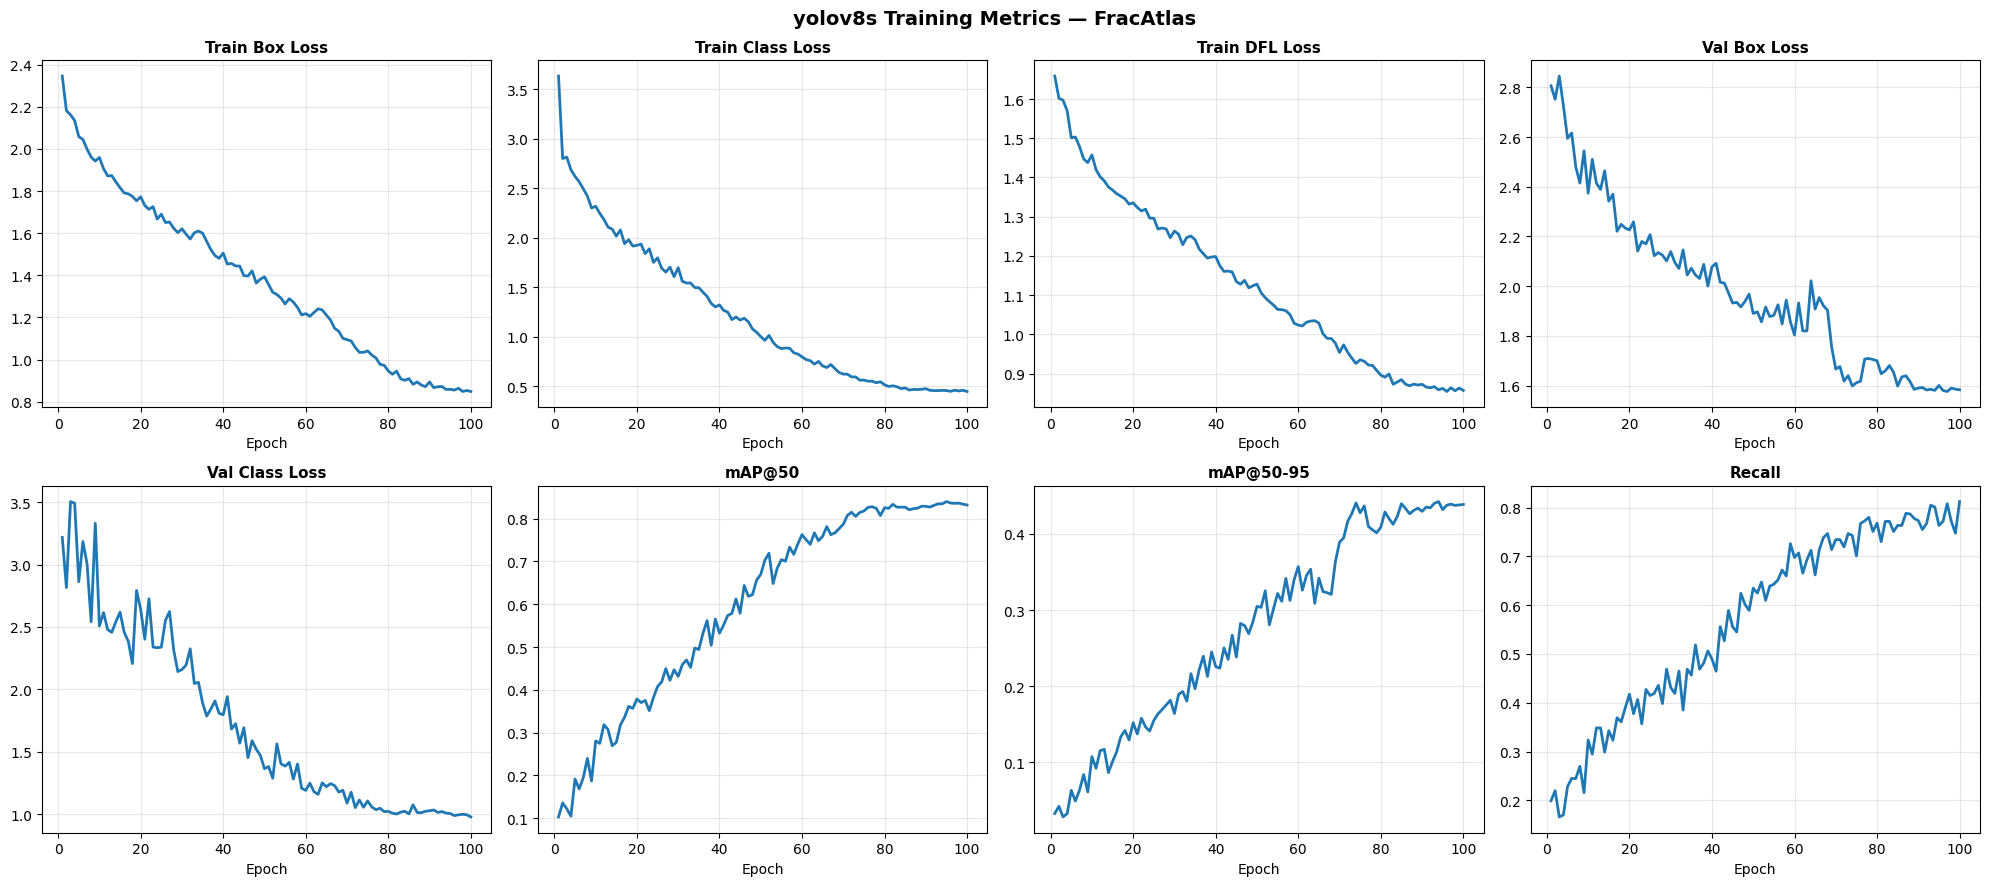

Saved: /content/FracAtlas/training_metrics.png


In [38]:
import matplotlib.pyplot as plt
import pandas as pd

results_csv = RUNS_DIR / RUN_NAME / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()   # Remove whitespace from col names
    print("Available columns:", df.columns.tolist())

    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    axes = axes.flatten()

    plot_cols = [
        ("train/box_loss", "Train Box Loss"),
        ("train/cls_loss", "Train Class Loss"),
        ("train/dfl_loss", "Train DFL Loss"),
        ("val/box_loss",   "Val Box Loss"),
        ("val/cls_loss",   "Val Class Loss"),
        ("metrics/mAP50(B)",    "mAP@50"),
        ("metrics/mAP50-95(B)", "mAP@50-95"),
        ("metrics/recall(B)",   "Recall"),
    ]

    for ax, (col, title) in zip(axes, plot_cols):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linewidth=2)
            ax.set_title(title, fontsize=11, fontweight="bold")
            ax.set_xlabel("Epoch")
            ax.grid(True, alpha=0.3)
        else:
            ax.set_title(f"{title}\n(column not found)", fontsize=10)
            ax.axis('off')

    plt.suptitle("yolov8s Training Metrics — FracAtlas", fontsize=14, fontweight="bold")
    plt.tight_layout()
    save_path = BASE_DIR / "training_metrics.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")
else:
    print(f"results.csv not found at {results_csv}")


## 7. Best Model Summary

In [39]:
best_pt = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
last_pt = RUNS_DIR / RUN_NAME / "weights" / "last.pt"

print("=" * 50)
print("  TRAINING SUMMARY")
print("=" * 50)
print(f"Best weights : {best_pt}")
print(f"Last weights : {last_pt}")
print(f"Best exists  : {best_pt.exists()}")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    if "metrics/mAP50(B)" in df.columns:
        best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]

        print(f"\nBest epoch   : {int(best_row['epoch'])}")
        print(f"mAP@50       : {best_row['metrics/mAP50(B)']:.4f}")

        if "metrics/mAP50-95(B)" in df.columns:
            print(f"mAP@50-95    : {best_row['metrics/mAP50-95(B)']:.4f}")

        if "metrics/recall(B)" in df.columns:
            print(f"Recall       : {best_row['metrics/recall(B)']:.4f}")

        if "metrics/precision(B)" in df.columns:
            print(f"Precision    : {best_row['metrics/precision(B)']:.4f}")

        if "metrics/f1_score(B)" in df.columns:
            print(f"F1-score     : {best_row['metrics/f1_score(B)']:.4f}")

        if "metrics/specificity(B)" in df.columns:
            print(f"Specificity  : {best_row['metrics/specificity(B)']:.4f}")

print("\nProceed to Notebook 03 for evaluation.")

  TRAINING SUMMARY
Best weights : /content/FracAtlas/runs/detect/fracatlas_yolov8m_adamw/weights/best.pt
Last weights : /content/FracAtlas/runs/detect/fracatlas_yolov8m_adamw/weights/last.pt
Best exists  : True

Best epoch   : 95
mAP@50       : 0.8399
mAP@50-95    : 0.4320
Recall       : 0.7635
Precision    : 0.8876

Proceed to Notebook 03 for evaluation.


## 8. Inference Speed Benchmark (FPS)

In [40]:
# ─── INFERENCE SPEED BENCHMARK ───────────────────────────────────────────────
# Mengukur kecepatan inferensi model pada GPU untuk keperluan paper
import time
import numpy as np
from ultralytics import YOLO

best_pt = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
model_bench = YOLO(str(best_pt))

# Ambil satu gambar dari test set sebagai input
dataset_path = Path(data_cfg["path"])
test_imgs = sorted((dataset_path / "test" / "images").iterdir())
sample_img = str(test_imgs[0])

# Warmup GPU (10 iterasi)
print("Warming up GPU...")
for _ in range(10):
    _ = model_bench.predict(sample_img, verbose=False, imgsz=640)

# Benchmark (100 iterasi)
N_ITER = 100
print(f"Benchmarking ({N_ITER} iterations)...")
times = []
for _ in range(N_ITER):
    t0 = time.perf_counter()
    model_bench.predict(sample_img, verbose=False, imgsz=640)
    times.append(time.perf_counter() - t0)

avg_ms  = np.mean(times) * 1000
std_ms  = np.std(times)  * 1000
fps     = 1000 / avg_ms

print()
print("=" * 50)
print("  INFERENCE SPEED BENCHMARK")
print("=" * 50)
print(f"Model      : {MODEL_WEIGHTS}")
print(f"Image size : 640 x 640 px")
print(f"Device     : GPU ({torch.cuda.get_device_name(0)})")
print(f"Iterations : {N_ITER}")
print(f"Avg latency: {avg_ms:.2f} +/- {std_ms:.2f} ms/image")
print(f"FPS        : {fps:.1f}")


Warming up GPU...
Benchmarking (100 iterations)...

  INFERENCE SPEED BENCHMARK
Model      : yolov8m.pt
Image size : 640 x 640 px
Device     : GPU (Tesla T4)
Iterations : 100
Avg latency: 45.85 +/- 5.24 ms/image
FPS        : 21.8


## 9. Test Set Evaluation & Confusion Matrix

In [41]:
# ─── TEST SET EVALUATION ─────────────────────────────────────────────────────
# Evaluasi model pada test set (bukan val set) — metrik final untuk paper
# Confusion matrix + PR curve disimpan otomatis ke folder test_eval/
from ultralytics import YOLO
from pathlib import Path

best_pt = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
model_eval = YOLO(str(best_pt))

TEST_EVAL_DIR = RUNS_DIR / RUN_NAME / "test_eval"

print("Evaluating on TEST set...")
results_test = model_eval.val(
    data    = str(YAML_PATH),
    split   = "test",       # Pakai test split (bukan val)
    imgsz   = IMGSZ,
    conf    = 0.001,        # Standard: 0.001 untuk mAP calculation yang benar
    iou     = 0.5,
    augment = True,         # TTA: Test-Time Augmentation
    plots   = True,         # Otomatis simpan confusion matrix + PR curve
    save_dir = str(TEST_EVAL_DIR),
    verbose = True,
)

# Hitung F1
p  = results_test.box.mp
r  = results_test.box.mr
f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0

print()
print("=" * 50)
print("  TEST SET EVALUATION SUMMARY")
print("=" * 50)
print(f"mAP@50      : {results_test.box.map50:.4f}")
print(f"mAP@50-95   : {results_test.box.map:.4f}")
print(f"Precision   : {p:.4f}")
print(f"Recall      : {r:.4f}")
print(f"F1-Score    : {f1:.4f}")
print(f"\nConfusion matrix & PR curve saved to:")
print(f"  {TEST_EVAL_DIR}")


Evaluating on TEST set...
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 13.5±2.3 MB/s, size: 26.2 KB)
val: Scanning /content/FracAtlas/yolo_dataset_hand_oversampled/test/labels... 362 images, 165 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362 1.3Kit/s 0.3s
val: New cache created: /content/FracAtlas/yolo_dataset_hand_oversampled/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.2it/s 19.7s
                   all        362        253      0.858      0.779      0.839      0.401
Speed: 1.6ms preprocess, 48.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/FracAtlas/runs/detect/fracatlas_yolov8m_adamw/test_eval

  TEST SET EVALUATION SUMMARY
mAP@50      : 0.8395
mAP@50-95   : 0.4006
Precision   : 0.8582
Reca

## 10. Qualitative Visualization — Sample Predictions

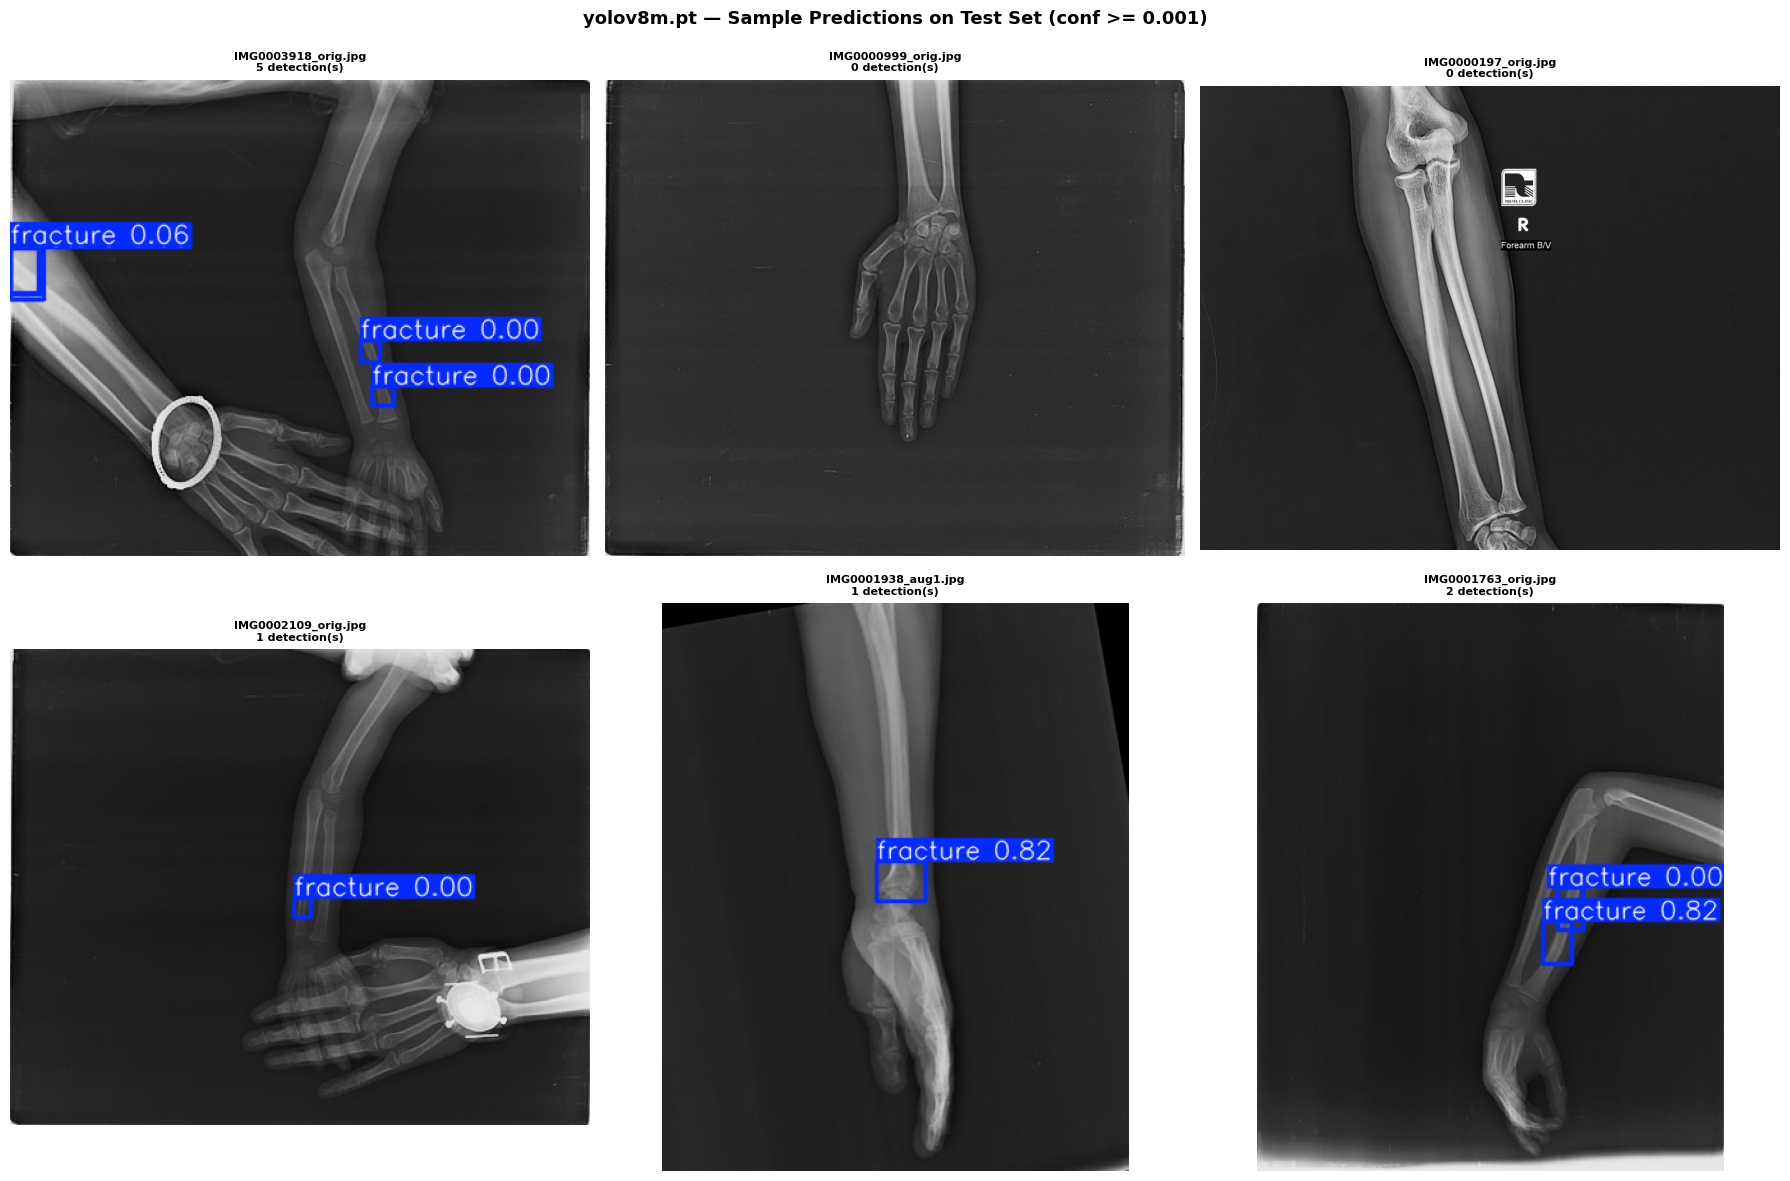

Saved: /content/FracAtlas/qualitative_fracatlas_yolov8m_adamw.png


In [42]:
# ─── QUALITATIVE VISUALIZATION ───────────────────────────────────────────────
# Menampilkan contoh prediksi model pada test set untuk visualisasi paper
# Menampilkan 6 gambar acak dari test set beserta bounding box prediksi
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

random.seed(42)  # Reproducibility

dataset_path = Path(data_cfg["path"])
test_imgs    = sorted((dataset_path / "test" / "images").iterdir())
sample_imgs  = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_path in enumerate(sample_imgs):
    result = model_eval.predict(
        str(img_path), verbose=False, imgsz=IMGSZ, conf=0.001
    )[0]
    img_annotated = result.plot(line_width=2, font_size=12)
    img_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    n_det = len(result.boxes) if result.boxes is not None else 0
    axes[i].set_title(
        f"{img_path.name}\n{n_det} detection(s)",
        fontsize=8, fontweight="bold"
    )
    axes[i].axis("off")

plt.suptitle(
    f"{MODEL_WEIGHTS} — Sample Predictions on Test Set (conf >= 0.001)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()

save_path = BASE_DIR / f"qualitative_{RUN_NAME}.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")


In [43]:
!mv "/content/FracAtlas" "/content/drive/MyDrive/FracAtlas_yolov8m/"
print("Folder hasil runs berhasil dipindahkan ke Google Drive!")

Folder hasil runs berhasil dipindahkan ke Google Drive!
